In [49]:
# Libraries
from sqlalchemy import create_engine, URL
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import numpy as np

In [50]:
load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME")
)

engine = create_engine(url)

In [51]:
query = """
SELECT s.steam_appid AS app_id, g.title,g.release_date, g.launch_price, g.reviews_total, g.reviews_score_fancy, g.tags, s.month, s.avg_players, s.peak_players
FROM steam s
INNER JOIN games g
ON s.steam_appid = g.app_id
INNER JOIN steam_summary ss
ON s.steam_appid = ss.steam_appid
WHERE ss.months_observed >= 24
ORDER BY s.steam_appid, s.month"""

lifecycle = pd.read_sql(query, engine)
lifecycle

,app_id,title,release_date,launch_price,reviews_total,reviews_score_fancy,tags,month,avg_players,peak_players
0,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-07-01,34139.20,53967
1,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-08-01,33095.80,53685
2,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-09-01,29432.56,55321
3,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-10-01,28836.29,56053
4,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-11-01,29669.97,56957
...,...,...,...,...,...,...,...,...,...,...
524541,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-04-01,1.13,4
524542,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-05-01,1.16,3
524543,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-06-01,1.01,3
524544,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-07-01,1.04,4


In [52]:
# Convert to datetime
lifecycle["month"] = pd.to_datetime(lifecycle["month"])
lifecycle["release_date"] = pd.to_datetime(
    lifecycle["release_date"],
    errors="coerce"
)

# Change month to lifecycle
lifecycle["month_since_release"] = (
    (lifecycle["month"].dt.year -
     lifecycle["release_date"].dt.year) * 12
    +
    (lifecycle["month"].dt.month -
     lifecycle["release_date"].dt.month)
)

lifecycle[["title", "month", "month_since_release", "avg_players"]].head(20)

,title,month,month_since_release,avg_players
0,Counter-Strike,2012-07-01,140,34139.20
1,Counter-Strike,2012-08-01,141,33095.80
2,Counter-Strike,2012-09-01,142,29432.56
3,Counter-Strike,2012-10-01,143,28836.29
4,Counter-Strike,2012-11-01,144,29669.97
5,Counter-Strike,2012-12-01,145,31996.07
6,Counter-Strike,2013-01-01,146,34814.47
7,Counter-Strike,2013-02-01,147,28378.42
8,Counter-Strike,2013-03-01,148,24139.15
9,Counter-Strike,2013-04-01,149,21204.46


In [53]:
# Only post-release observations
lifecycle = lifecycle[lifecycle["month_since_release"] >= 0].copy()

# Baseline = months 1-3 after release since month 0 is only a partial calendar month for many games
baseline = (
    lifecycle[lifecycle["month_since_release"].between(1, 3)]
    .groupby("app_id")["avg_players"]
    .mean()
    .rename("baseline_players")
)

lifecycle = lifecycle.merge(baseline, on="app_id", how="left")
lifecycle["relative_players"] = lifecycle["avg_players"] / lifecycle["baseline_players"]

In [54]:
# 6-month retention: months 5-7
relative_6m = (
    lifecycle[lifecycle["month_since_release"].between(5, 7)]
    .groupby("app_id")["relative_players"]
    .mean()
    .rename("relative_6m")
)

# 12-month retention: months 11-13
relative_12m = (
    lifecycle[lifecycle["month_since_release"].between(11, 13)]
    .groupby("app_id")["relative_players"]
    .mean()
    .rename("relative_12m")
)

# 24-month retention: months 23-25
relative_24m = (
    lifecycle[lifecycle["month_since_release"].between(23, 25)]
    .groupby("app_id")["relative_players"]
    .mean()
    .rename("relative_24m")
)

game_lifecycle = (
    lifecycle.groupby("app_id")
    .agg(
        title=("title", "first"),
        launch_price=("launch_price", "first"),
        reviews_total=("reviews_total", "first"),
        review_score=("reviews_score_fancy", "first"),
        tags=("tags", "first"),
        baseline_players=("baseline_players", "first")
    )
    .join(relative_6m)
    .join(relative_12m)
    .join(relative_24m)
    .reset_index()
)

In [55]:
game_lifecycle[["baseline_players", "relative_12m", "relative_24m"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

C:\Users\mingj\miniforge3\envs\videogame\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mingj\miniforge3\envs\videogame\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,baseline_players,relative_12m,relative_24m
count,4.053000e+03,4039.000000,3985.000000
mean,8.043574e+02,inf,inf
std,2.249670e+04,NaN,NaN
min,0.000000e+00,0.001127,0.000000
10%,3.766667e-01,0.235371,0.151755
25%,2.000000e+00,0.377646,0.285916
50%,1.454000e+01,0.613716,0.526863
75%,1.001900e+02,1.065382,1.004799
90%,5.825927e+02,2.017961,2.021030
max,1.423770e+06,inf,inf


In [56]:
# Early trajectory shape features: months 1–6 after release
def get_trajectory_features(group):
    early = group[group["month_since_release"].between(1, 6)].sort_values("month_since_release")

    players = early["avg_players"]

    if early["month_since_release"].nunique() >= 2:
        slope = np.polyfit(early["month_since_release"], np.log1p(players), 1)[0]
    else:
        slope = np.nan

    month_1 = early.loc[early["month_since_release"] == 1, "avg_players"].mean()

    month_6 = early.loc[early["month_since_release"] == 6, "avg_players"].mean()

    return pd.Series({
        "early_trend_slope": slope,
        "month_6_vs_month_1": (
            month_6 / month_1
            if pd.notna(month_1) and month_1 > 0
            else np.nan
        ),
        "early_volatility": (
            players.std() / players.mean()
            if players.mean() > 0
            else np.nan
        ),
        "early_peak_to_average": (
            players.max() / players.mean()
            if players.mean() > 0
            else np.nan
        ),
    })

early_trajectory_features = (
    lifecycle.groupby("app_id")
    .apply(get_trajectory_features)
    .reset_index()
)

game_lifecycle = game_lifecycle.merge(
    early_trajectory_features,
    on="app_id",
    how="left"
)

C:\Users\mingj\AppData\Local\Temp\ipykernel_11184\1419500079.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_trajectory_features)


In [57]:
for threshold in [1, 5, 10, 25, 50]:
    temp = game_lifecycle[
        game_lifecycle["baseline_players"] >= threshold
    ].dropna(
        subset=["relative_6m", "relative_12m", "relative_24m", "early_trend_slope", "month_6_vs_month_1", "early_volatility", "early_peak_to_average",]
    )

    print(
        f"Baseline >= {threshold:2}: "
        f"{len(temp):4} games | "
        f"median 24m = {temp['relative_24m'].median():.3f} | "
        f"99th pct = {temp['relative_24m'].quantile(.99):.3f}"
    )
# Choose 5 base line players to reduce unstable ratios caused by very small denominators while retaining a large sample of games

Baseline >=  1: 3267 games | median 24m = 0.507 | 99th pct = 7.968
Baseline >=  5: 2542 games | median 24m = 0.490 | 99th pct = 5.689
Baseline >= 10: 2206 games | median 24m = 0.484 | 99th pct = 5.692
Baseline >= 25: 1701 games | median 24m = 0.474 | 99th pct = 5.692
Baseline >= 50: 1344 games | median 24m = 0.464 | 99th pct = 5.730


In [58]:
game_lifecycle_clean = game_lifecycle[
    (game_lifecycle["baseline_players"] >= 5)
].copy()

game_lifecycle_clean = game_lifecycle_clean.dropna(
    subset=["relative_6m", "relative_12m", "relative_24m", "early_trend_slope", "month_6_vs_month_1", "early_volatility", "early_peak_to_average",]
)

print("Final games:", len(game_lifecycle_clean))

game_lifecycle_clean[
    [
        "baseline_players",
        "relative_6m",
        "relative_12m",
        "relative_24m"
    ]
].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

Final games: 2542


,baseline_players,relative_6m,relative_12m,relative_24m
count,2.542000e+03,2542.000000,2542.000000,2542.000000
mean,1.278295e+03,0.784024,0.824067,0.794891
std,2.839802e+04,1.144777,1.057493,1.369672
min,5.006667e+00,0.019471,0.001127,0.001544
10%,8.362000e+00,0.307921,0.251676,0.167230
25%,1.702333e+01,0.425392,0.381836,0.284050
50%,5.784333e+01,0.611235,0.574737,0.489944
75%,2.607800e+02,0.867918,0.910250,0.831644
90%,1.199952e+03,1.257252,1.480297,1.487355
95%,3.002756e+03,1.682367,2.125650,2.328444


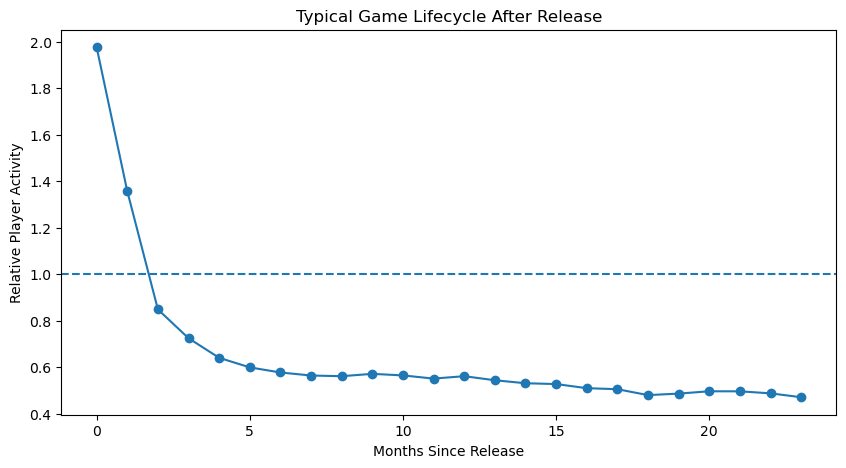

In [59]:
# Keep only valid games
valid_games = game_lifecycle_clean["app_id"]

lifecycle_clean = lifecycle[
    lifecycle["app_id"].isin(valid_games)
].copy()

# Look at first 24 months after release
first_24_months = lifecycle_clean[
    lifecycle_clean["month_since_release"].between(0, 23)
]

# Median relative player activity by month since release
typical_lifecycle = (
    first_24_months
    .groupby("month_since_release")["relative_players"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    typical_lifecycle["month_since_release"],
    typical_lifecycle["relative_players"],
    marker="o"
)

plt.axhline(1, linestyle="--")

plt.xlabel("Months Since Release")
plt.ylabel("Relative Player Activity")
plt.title("Typical Game Lifecycle After Release")

plt.show()

In [61]:
game_lifecycle_clean.to_csv("../data/processed/game_lifecycle_clean.csv", index=False)